In [59]:
from scripts.getQuartets import *
import numpy as np
from matplotlib import pyplot as plt

In [60]:
FACTORS = ["0.5", "1.0", "2.0", "4.0", "8.0"]
POLYMORPHISM = ["modhigh", "veryhigh", "mod", "high", "low"]
METHODS = ["ASTRAL", "MP4"]

In [61]:
def get_data(score_path="./inference_outputs/scores.txt", method=None, has_morph: str = ""):
    print(f"path = {score_path}")
    data = {'score': [], 'polymorphism': [], 'factor': [], 'method': [], 'has_morph': []}
    with open(score_path) as f:
        lines = f.read().split('\n')
        N = len(lines)
        for i in range(0, N - 1, 2):
            filename = lines[i]
            score = float(lines[i + 1].split()[1])        
            if(score < 0):
                print("Negative value: ", filename)
                continue
            data['score'].append(score * 100)
            for p in POLYMORPHISM:
                if p in filename:
                    data['polymorphism'].append(p)
                    break
            for f in FACTORS:
                if f in filename:
                    data['factor'].append(f)
                    break
            data['method'].append(method)
            data['has_morph'].append(has_morph)
            # print(s, score)
    return data


In [62]:

data = {
    'score': [],
    'polymorphism': [],
    'method': [],
    'factor': [],
    'summary': [],
    'has_morph': []
}
hue_ord = []
for f in FACTORS:
    for m in METHODS:
        data_ = get_data(f"/Users/liusean/Desktop/Projects/Coding/Phylo/QuartetMethods/outputs_no_morph/inference_outputs-{f}/{m}/allscores.txt", m, has_morph='No morphological chrs.')
        data['score'] += data_['score']
        data['polymorphism'] += data_['polymorphism']
        data['method'] += [ m for m in data_['method'] ]
        data['factor'] += data_['factor']
        data['has_morph'] += data_['has_morph']
        data['summary'] += [f'{m}-{p}' for m, p in zip(data_['method'], data_['polymorphism'])]
POLYMORPHISM

for p in ["low", "mod", "modhigh", "high", "veryhigh"]:
    for m in METHODS:
        hue_ord.append(f'{m}-{p}')

data_nomorph = data

path = /Users/liusean/Desktop/Projects/Coding/Phylo/QuartetMethods/outputs_no_morph/inference_outputs-0.5/ASTRAL/allscores.txt
path = /Users/liusean/Desktop/Projects/Coding/Phylo/QuartetMethods/outputs_no_morph/inference_outputs-0.5/MP4/allscores.txt
path = /Users/liusean/Desktop/Projects/Coding/Phylo/QuartetMethods/outputs_no_morph/inference_outputs-1.0/ASTRAL/allscores.txt
path = /Users/liusean/Desktop/Projects/Coding/Phylo/QuartetMethods/outputs_no_morph/inference_outputs-1.0/MP4/allscores.txt
path = /Users/liusean/Desktop/Projects/Coding/Phylo/QuartetMethods/outputs_no_morph/inference_outputs-2.0/ASTRAL/allscores.txt
path = /Users/liusean/Desktop/Projects/Coding/Phylo/QuartetMethods/outputs_no_morph/inference_outputs-2.0/MP4/allscores.txt
path = /Users/liusean/Desktop/Projects/Coding/Phylo/QuartetMethods/outputs_no_morph/inference_outputs-4.0/ASTRAL/allscores.txt
path = /Users/liusean/Desktop/Projects/Coding/Phylo/QuartetMethods/outputs_no_morph/inference_outputs-4.0/MP4/allscores.

In [63]:
import seaborn as sns

In [64]:

data = {
    'score': [],
    'polymorphism': [],
    'method': [],
    'factor': [],
    'summary': [],
    'has_morph': []
}
hue_ord = []
for f in FACTORS:
    for m in METHODS:
        data_ = get_data(f"/Users/liusean/Desktop/Projects/Coding/Phylo/QuartetMethods/outputs_with_morph/inference_outputs-{f}/{m}/allscores.txt", m, has_morph="With morphological chars.")
        data['score'] += data_['score']
        data['polymorphism'] += data_['polymorphism']
        data['method'] += data_['method']
        data['factor'] += data_['factor']
        data['has_morph'] += data_['has_morph']
        data['summary'] += [f'{m}-{p}' for m, p in zip(data_['method'], data_['polymorphism'])]

for p in POLYMORPHISM:
    for m in METHODS:
        hue_ord.append(f'{m}-{p}')

data_morph = data

path = /Users/liusean/Desktop/Projects/Coding/Phylo/QuartetMethods/outputs_with_morph/inference_outputs-0.5/ASTRAL/allscores.txt
path = /Users/liusean/Desktop/Projects/Coding/Phylo/QuartetMethods/outputs_with_morph/inference_outputs-0.5/MP4/allscores.txt
path = /Users/liusean/Desktop/Projects/Coding/Phylo/QuartetMethods/outputs_with_morph/inference_outputs-1.0/ASTRAL/allscores.txt
path = /Users/liusean/Desktop/Projects/Coding/Phylo/QuartetMethods/outputs_with_morph/inference_outputs-1.0/MP4/allscores.txt
path = /Users/liusean/Desktop/Projects/Coding/Phylo/QuartetMethods/outputs_with_morph/inference_outputs-2.0/ASTRAL/allscores.txt
path = /Users/liusean/Desktop/Projects/Coding/Phylo/QuartetMethods/outputs_with_morph/inference_outputs-2.0/MP4/allscores.txt
path = /Users/liusean/Desktop/Projects/Coding/Phylo/QuartetMethods/outputs_with_morph/inference_outputs-4.0/ASTRAL/allscores.txt
path = /Users/liusean/Desktop/Projects/Coding/Phylo/QuartetMethods/outputs_with_morph/inference_outputs-4.

In [65]:
def merge_datas(A, B):
    for x, t in A.items():
        B[x] += t
        print(x)
    return B

In [66]:
data = merge_datas(data_morph, data_nomorph)
df = pd.DataFrame(data)
df_morph = pd.DataFrame(data_morph)
df_nomorph = pd.DataFrame(data_nomorph)

score
polymorphism
method
factor
summary
has_morph


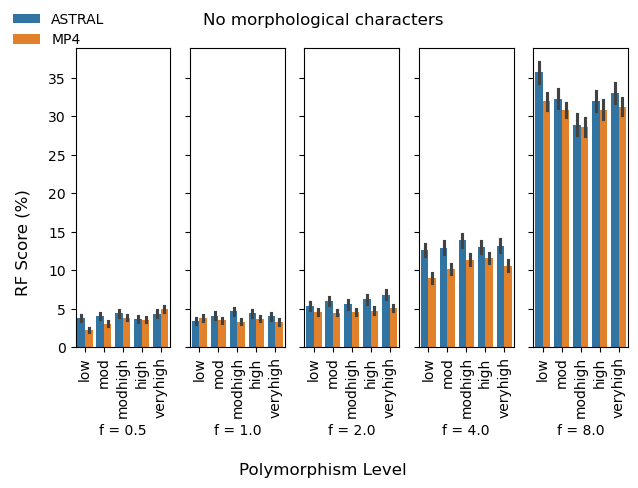

In [67]:
fig, axes = plt.subplots(1, 5, sharey=True)
fig.suptitle("No morphological characters")
fig.supylabel("RF Score (%)")
fig.supxlabel("Polymorphism Level")
loc, labels = plt.xticks()
for f, ax in zip(FACTORS, axes):
    sns.barplot(ax=ax, data=df_nomorph[df_nomorph["factor"] == f], x='polymorphism', y='score', hue='method', errorbar='se')
    ax.get_legend().remove()
    ax.set_xlabel(f"f = {f}")
    ax.set_ylabel("")
    ax.tick_params(axis='x', rotation=90)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig("figs/method-no")

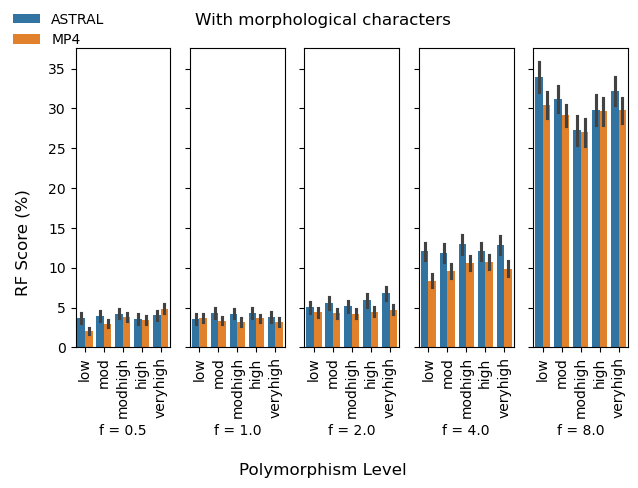

In [68]:
from matplotlib.legend import _get_legend_handles_labels
fig, axes = plt.subplots(1, 5, sharey=True)
fig.suptitle("With morphological characters")
fig.supylabel("RF Score (%)")
fig.supxlabel("Polymorphism Level")
loc, labels = plt.xticks()
for f, ax in zip(FACTORS, axes):
    sns.barplot(ax=ax, data=df_morph[df_morph["factor"] == f], x='polymorphism', y='score', hue='method', errorbar='se')
    ax.get_legend().remove()
    ax.set_xlabel(f"f = {f}")
    ax.set_ylabel("")
    ax.tick_params(axis='x', rotation=90)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig("figs/method-with")

In [69]:
no_morph_errors = df_nomorph.groupby(["factor", "method", "polymorphism"])["score"].aggregate("mean")
no_morph_errors_np = np.array(no_morph_errors)

In [70]:
morph_errors = df_morph.groupby(["factor", "method", "polymorphism"])["score"].aggregate("mean")
morph_errors_np = np.array(morph_errors)

In [71]:
morph_advantage = no_morph_errors - morph_errors

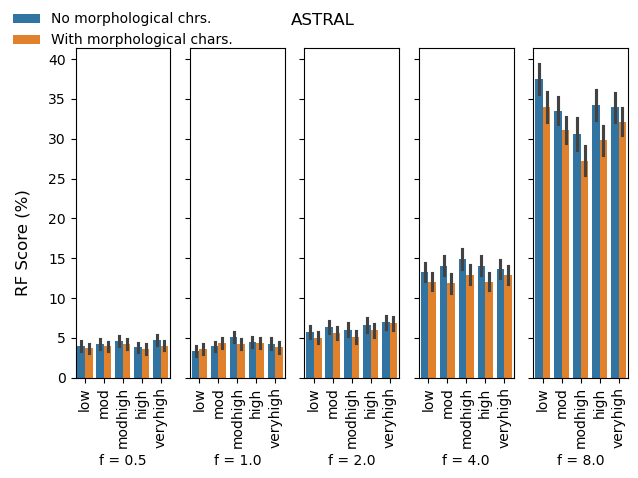

In [72]:
target_method = "ASTRAL"
from matplotlib.legend import _get_legend_handles_labels
fig, axes = plt.subplots(1, 5, sharey=True)

fig.suptitle(target_method)
fig.supylabel("RF Score (%)")
loc, labels = plt.xticks()
df_ = df[df["method"] == target_method]
for f, ax in zip(FACTORS, axes):
    sns.barplot(ax=ax, data=df_[df_["factor"] == f], x='polymorphism', y='score', hue='has_morph', errorbar='se')
    ax.get_legend().remove()
    ax.set_xlabel(f"f = {f}")
    ax.set_ylabel("")
    ax.tick_params(axis='x', rotation=90)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig("figs/morph-astral")

In [73]:
df_[df_["factor"] == "0.5"]

,score,polymorphism,method,factor,summary,has_morph
0,14.285714,low,ASTRAL,0.5,ASTRAL-low,No morphological chrs.
1,0.000000,low,ASTRAL,0.5,ASTRAL-low,No morphological chrs.
2,0.000000,low,ASTRAL,0.5,ASTRAL-low,No morphological chrs.
3,0.000000,low,ASTRAL,0.5,ASTRAL-low,No morphological chrs.
4,0.000000,low,ASTRAL,0.5,ASTRAL-low,No morphological chrs.
...,...,...,...,...,...,...
7034,14.285714,veryhigh,ASTRAL,0.5,ASTRAL-veryhigh,With morphological chars.
7035,0.000000,veryhigh,ASTRAL,0.5,ASTRAL-veryhigh,With morphological chars.
7036,14.285714,veryhigh,ASTRAL,0.5,ASTRAL-veryhigh,With morphological chars.
7037,14.285714,veryhigh,ASTRAL,0.5,ASTRAL-veryhigh,With morphological chars.


In [74]:
dff = df[df["method"] == 'ASTRAL']
dff = dff[dff["factor"] == "0.5"]
print(list(dff.groupby('has_morph')))

[('No morphological chrs.',          score polymorphism  method factor          summary  \
0    14.285714          low  ASTRAL    0.5       ASTRAL-low   
1     0.000000          low  ASTRAL    0.5       ASTRAL-low   
2     0.000000          low  ASTRAL    0.5       ASTRAL-low   
3     0.000000          low  ASTRAL    0.5       ASTRAL-low   
4     0.000000          low  ASTRAL    0.5       ASTRAL-low   
..         ...          ...     ...    ...              ...   
635  14.285714     veryhigh  ASTRAL    0.5  ASTRAL-veryhigh   
636   0.000000     veryhigh  ASTRAL    0.5  ASTRAL-veryhigh   
637  14.285714     veryhigh  ASTRAL    0.5  ASTRAL-veryhigh   
638  14.285714     veryhigh  ASTRAL    0.5  ASTRAL-veryhigh   
639  28.571429     veryhigh  ASTRAL    0.5  ASTRAL-veryhigh   

                  has_morph  
0    No morphological chrs.  
1    No morphological chrs.  
2    No morphological chrs.  
3    No morphological chrs.  
4    No morphological chrs.  
..                      ...  
635  

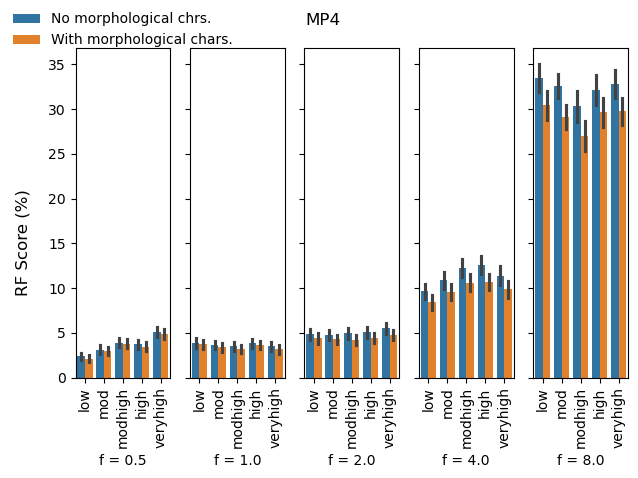

In [75]:
target_method = "MP4"
from matplotlib.legend import _get_legend_handles_labels
fig, axes = plt.subplots(1, 5, sharey=True)

fig.suptitle(target_method)
fig.supylabel("RF Score (%)")
loc, labels = plt.xticks()
df_ = df[df["method"] == target_method]
for f, ax in zip(FACTORS, axes):
    sns.barplot(ax=ax, data=df_[df_["factor"] == f], x='polymorphism', y='score', hue='has_morph', errorbar='se')
    ax.get_legend().remove()
    ax.set_xlabel(f"f = {f}")
    ax.set_ylabel("")
    ax.tick_params(axis='x', rotation=90)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig("figs/morph-mp4")

In [ ]:
df_ = df[df["method"] == "ASTRAL"]
data=df_[df_["factor"] == f]
data

,score,polymorphism,method,factor,summary,has_morph
5759,14.285714,low,ASTRAL,0.5,ASTRAL-low,With morphological chars.
5760,0.000000,low,ASTRAL,0.5,ASTRAL-low,With morphological chars.
5761,0.000000,low,ASTRAL,0.5,ASTRAL-low,With morphological chars.
5762,0.000000,low,ASTRAL,0.5,ASTRAL-low,With morphological chars.
5763,0.000000,low,ASTRAL,0.5,ASTRAL-low,With morphological chars.
